# **Import Libraries**

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# **Importing CSV Files**

In [ ]:
df = pd.read_csv("/content/drive/MyDrive/healthcare_dataset.csv")     ## Dataset From Kaggle

# **Exploratory Data Analysis**

In [ ]:
df.head()

,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results
0,Bobby JacksOn,30,Male,B-,Cancer,2024-01-31,Matthew Smith,Sons and Miller,Blue Cross,18856.281306,328,Urgent,2024-02-02,Paracetamol,Normal
1,LesLie TErRy,62,Male,A+,Obesity,2019-08-20,Samantha Davies,Kim Inc,Medicare,33643.327287,265,Emergency,2019-08-26,Ibuprofen,Inconclusive
2,DaNnY sMitH,76,Female,A-,Obesity,2022-09-22,Tiffany Mitchell,Cook PLC,Aetna,27955.096079,205,Emergency,2022-10-07,Aspirin,Normal
3,andrEw waTtS,28,Female,O+,Diabetes,2020-11-18,Kevin Wells,"Hernandez Rogers and Vang,",Medicare,37909.782410,450,Elective,2020-12-18,Ibuprofen,Abnormal
4,adrIENNE bEll,43,Female,AB+,Cancer,2022-09-19,Kathleen Hanna,White-White,Aetna,14238.317814,458,Urgent,2022-10-09,Penicillin,Abnormal


In [ ]:
df.tail()

,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results
55495,eLIZABeTH jaCkSOn,42,Female,O+,Asthma,2020-08-16,Joshua Jarvis,Jones-Thompson,Blue Cross,2650.714952,417,Elective,2020-09-15,Penicillin,Abnormal
55496,KYle pEREz,61,Female,AB-,Obesity,2020-01-23,Taylor Sullivan,Tucker-Moyer,Cigna,31457.797307,316,Elective,2020-02-01,Aspirin,Normal
55497,HEATher WaNG,38,Female,B+,Hypertension,2020-07-13,Joe Jacobs DVM,"and Mahoney Johnson Vasquez,",UnitedHealthcare,27620.764717,347,Urgent,2020-08-10,Ibuprofen,Abnormal
55498,JENniFER JOneS,43,Male,O-,Arthritis,2019-05-25,Kimberly Curry,"Jackson Todd and Castro,",Medicare,32451.092358,321,Elective,2019-05-31,Ibuprofen,Abnormal
55499,jAMES GARCiA,53,Female,O+,Arthritis,2024-04-02,Dennis Warren,Henry Sons and,Aetna,4010.134172,448,Urgent,2024-04-29,Ibuprofen,Abnormal


In [ ]:
df.shape

(55500, 15)

#The Dataset contain:
55500 rows(55,500 Patient records)

15 columns (15 different features or variables related to healthcare information)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 55500 entries, 0 to 55499
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Name                55500 non-null  object 
 1   Age                 55500 non-null  int64  
 2   Gender              55500 non-null  object 
 3   Blood Type          55500 non-null  object 
 4   Medical Condition   55500 non-null  object 
 5   Date of Admission   55500 non-null  object 
 6   Doctor              55500 non-null  object 
 7   Hospital            55500 non-null  object 
 8   Insurance Provider  55500 non-null  object 
 9   Billing Amount      55500 non-null  float64
 10  Room Number         55500 non-null  int64  
 11  Admission Type      55500 non-null  object 
 12  Discharge Date      55500 non-null  object 
 13  Medication          55500 non-null  object 
 14  Test Results        55500 non-null  object 
dtypes: float64(1), int64(2), object(12)
memory usage: 6.4

#**check missing values**

In [ ]:
df.isnull().sum()

,0
Name,0
Age,0
Gender,0
Blood Type,0
Medical Condition,0
Date of Admission,0
Doctor,0
Hospital,0
Insurance Provider,0
Billing Amount,0


In [ ]:
df1= (df.isnull().sum()/len(df)*100).sort_values(ascending=False)
print(df1)

Name                  0.0
Age                   0.0
Gender                0.0
Blood Type            0.0
Medical Condition     0.0
Date of Admission     0.0
Doctor                0.0
Hospital              0.0
Insurance Provider    0.0
Billing Amount        0.0
Room Number           0.0
Admission Type        0.0
Discharge Date        0.0
Medication            0.0
Test Results          0.0
dtype: float64


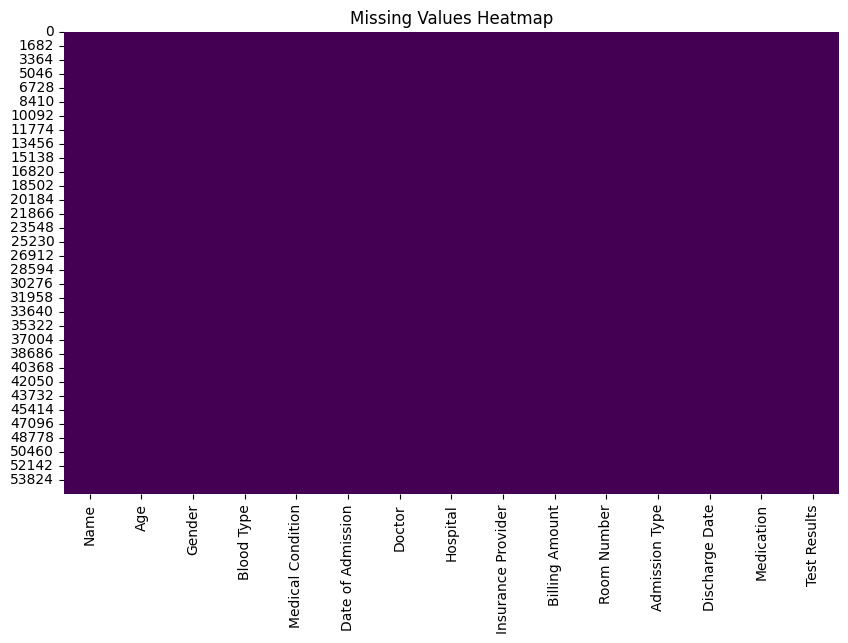

In [ ]:
plt.figure(figsize=(10,6))
sns.heatmap(df.isnull(),cbar=False,cmap="viridis")
plt.title("Missing Values Heatmap")
plt.show()

In [ ]:
df.describe()

,Age,Billing Amount,Room Number
count,55500.000000,55500.000000,55500.000000
mean,51.539459,25539.316097,301.134829
std,19.602454,14211.454431,115.243069
min,13.000000,-2008.492140,101.000000
25%,35.000000,13241.224652,202.000000
50%,52.000000,25538.069376,302.000000
75%,68.000000,37820.508436,401.000000
max,89.000000,52764.276736,500.000000


In [ ]:
print(df.columns.tolist())

['Name', 'Age', 'Gender', 'Blood Type', 'Medical Condition', 'Date of Admission', 'Doctor', 'Hospital', 'Insurance Provider', 'Billing Amount', 'Room Number', 'Admission Type', 'Discharge Date', 'Medication', 'Test Results']


#**Check duplicate records**

In [ ]:
print("duplicate rows:",df.duplicated().sum())

duplicate rows: 534


#**Remove duplicates if appropriate:**

In [ ]:
df=df.drop_duplicates()
print("New shape:",df.shape)

New shape: (54966, 15)


#**Check unique values**

In [ ]:
for col in df.columns:
  unique_values = df[col].unique()
  print(f"Unique values in column '{col}':")
  print(unique_values)
  print()

Unique values in column 'Name':
['Bobby JacksOn' 'LesLie TErRy' 'DaNnY sMitH' ... 'LiSa sIMPsoN'
 'RoGER farRELl' 'kaTheRIne WeBSTer']

Unique values in column 'Age':
[30 62 76 28 43 36 21 20 82 58 72 38 75 68 44 46 63 34 67 48 59 73 51 23
 78 25 33 26 70 57 74 81 49 65 31 22 77 42 24 84 55 40 83 18 27 19 29 61
 80 60 35 79 53 69 47 85 52 37 50 32 54 45 66 39 56 64 71 41 88 17 87 86
 15 16 13 14 89]

Unique values in column 'Gender':
['Male' 'Female']

Unique values in column 'Blood Type':
['B-' 'A+' 'A-' 'O+' 'AB+' 'AB-' 'B+' 'O-']

Unique values in column 'Medical Condition':
['Cancer' 'Obesity' 'Diabetes' 'Asthma' 'Hypertension' 'Arthritis']

Unique values in column 'Date of Admission':
['2024-01-31' '2019-08-20' '2022-09-22' ... '2019-05-31' '2023-10-12'
 '2021-03-14']

Unique values in column 'Doctor':
['Matthew Smith' 'Samantha Davies' 'Tiffany Mitchell' ... 'Deborah Sutton'
 'Mary Bartlett' 'Alec May']

Unique values in column 'Hospital':
['Sons and Miller' 'Kim Inc' 'Cook PLC' 

#**Check categorical columns**

In [ ]:
categorical_columns = df.select_dtypes(include=["object"]).columns
print("Categorical Columns:")
print(categorical_columns)

Categorical Columns:
Index(['Name', 'Gender', 'Blood Type', 'Medical Condition',
       'Date of Admission', 'Doctor', 'Hospital', 'Insurance Provider',
       'Admission Type', 'Discharge Date', 'Medication', 'Test Results'],
      dtype='object')


#**Check numerical columns**

In [ ]:
numerical_columns = df.select_dtypes(include=np.number).columns
print("Numerical Columns:")
print(numerical_columns)

Numerical Columns:
Index(['Age', 'Billing Amount', 'Room Number'], dtype='object')


#**Correlation Heatmap**

The heatmap shows the strength and direction of relationships between numerical variables.

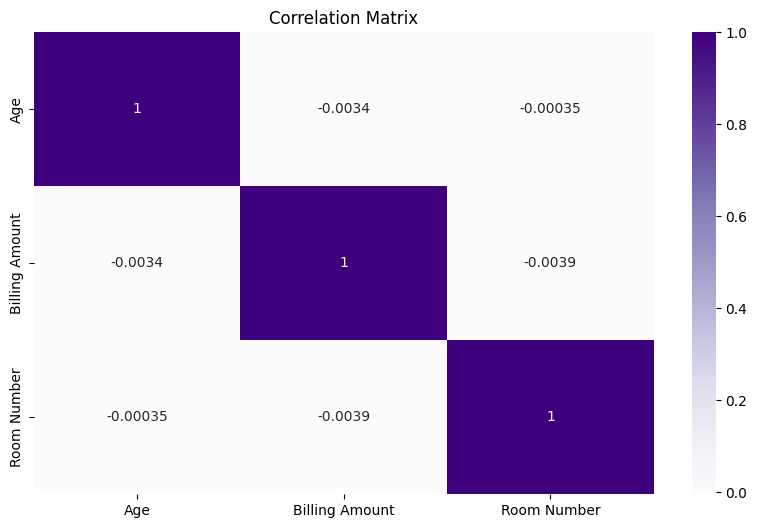

In [ ]:
correlation_matrix = df[numerical_columns].corr()
plt.figure(figsize=(10,6))
sns.heatmap(correlation_matrix,annot=True,cmap="Purples")
plt.title("Correlation Matrix")
plt.show()

#**Target Variable**

In [ ]:
print(df["Medical Condition"].value_counts())

Medical Condition
Arthritis       9218
Diabetes        9216
Hypertension    9151
Obesity         9146
Cancer          9140
Asthma          9095
Name: count, dtype: int64


In [ ]:
Target= "Test Results"

In [ ]:
print(df[Target].value_counts())

Test Results
Abnormal        18437
Normal          18331
Inconclusive    18198
Name: count, dtype: int64


# **Visualize target classes**

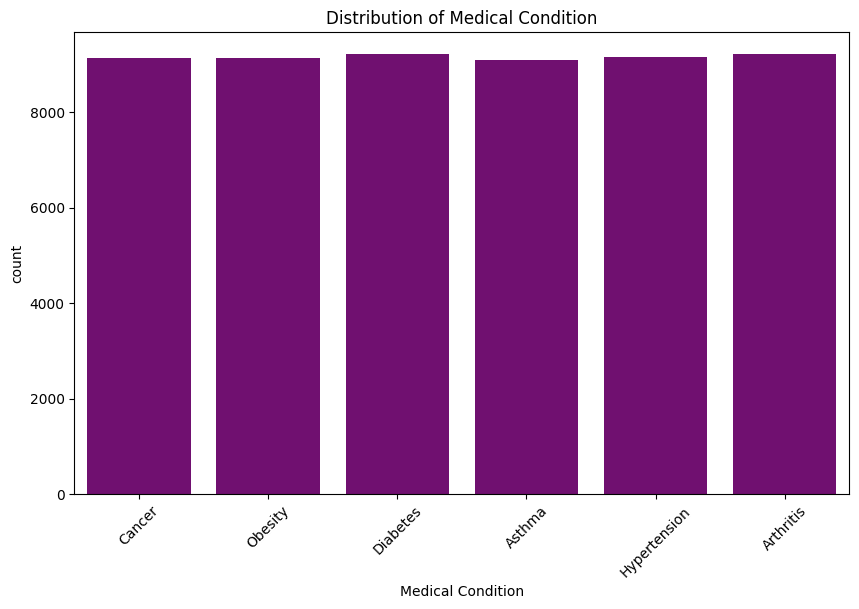

In [ ]:
plt.figure(figsize=(10,6))
sns.countplot(data=df,x="Medical Condition",color="purple")
plt.title("Distribution of Medical Condition")
plt.xticks(rotation=45)
plt.show()

" The distribution of medical conditions is approximately balanced, as each category has a similar number of records.
This balanced distribution is beneficial for developing an unbiased multi-class classification model"

# **Gender Distribution**

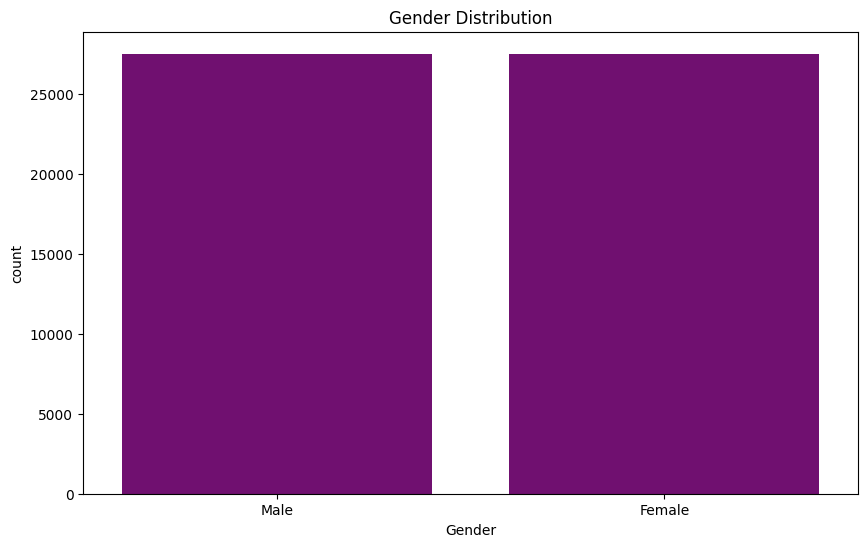

In [ ]:
plt.figure(figsize=(10,6))
sns.countplot(data=df,x="Gender",color="purple")
plt.title("Gender Distribution")
plt.show()

" The gender distribution graph shows the number of male and female patients in this dataset, both bars are approximately equal which indicates that the dataset is balanced in term of gender represenation, with no significant dominance of one gender."

# Age Distribution

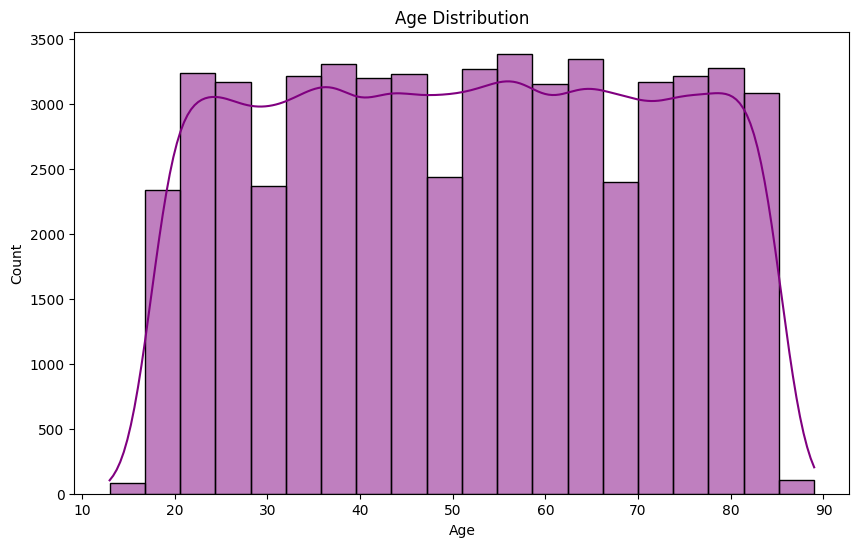

In [ ]:
plt.figure(figsize=(10,6))
sns.histplot(data=df,x="Age",color="purple",bins=20,kde=True)
plt.title("Age Distribution")
plt.show()

"The above graph shows a uniform distribution of ages across the dataset. the flat trendlines confirms that no single age group dominates, meaning the data is evenly spread across all ages"

# Medical condition Vs Gender

/tmp/ipykernel_4015/3096535996.py:2: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:purple'` for the same effect.

  sns.countplot(data=df,x="Medical Condition",hue="Gender",color="purple")


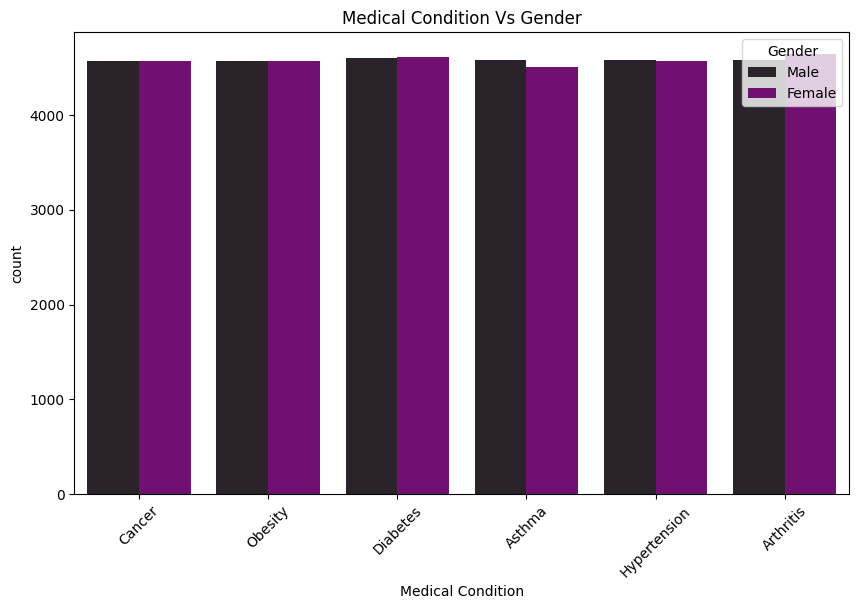

In [ ]:
plt.figure(figsize=(10,6))
sns.countplot(data=df,x="Medical Condition",hue="Gender",color="purple")
plt.title("Medical Condition Vs Gender")
plt.xticks(rotation=45)
plt.show()


" In the above graph for every medical condition listed, the count of male and Female patients is virtually identical, with each group hovering around the same frequency."

# **Billing amount analysis**

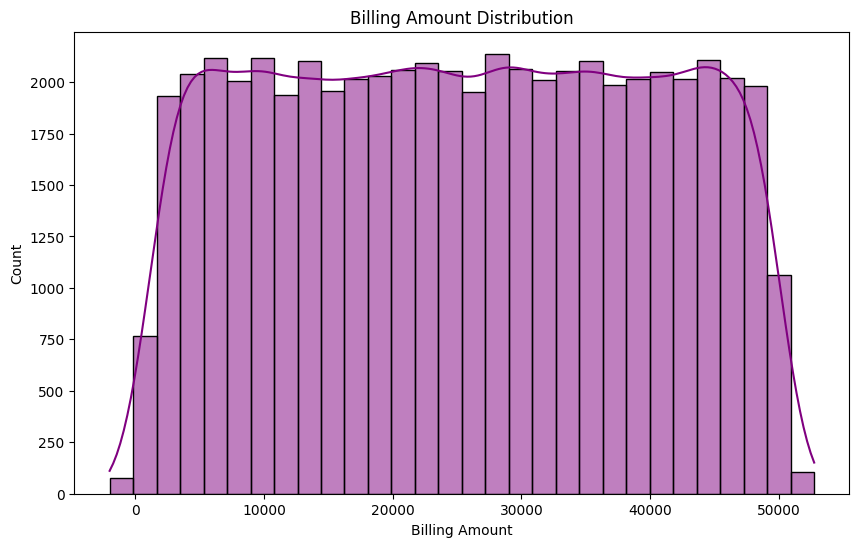

In [ ]:
plt.figure(figsize=(10,6))
sns.histplot(data=df,x="Billing Amount",color="purple",bins=30,kde=True)
plt.title("Billing Amount Distribution")
plt.show()

" This flat profile indicates that every biling amount within this range occurs with roughly the same frequency."

# **Billing amount by medical condition**

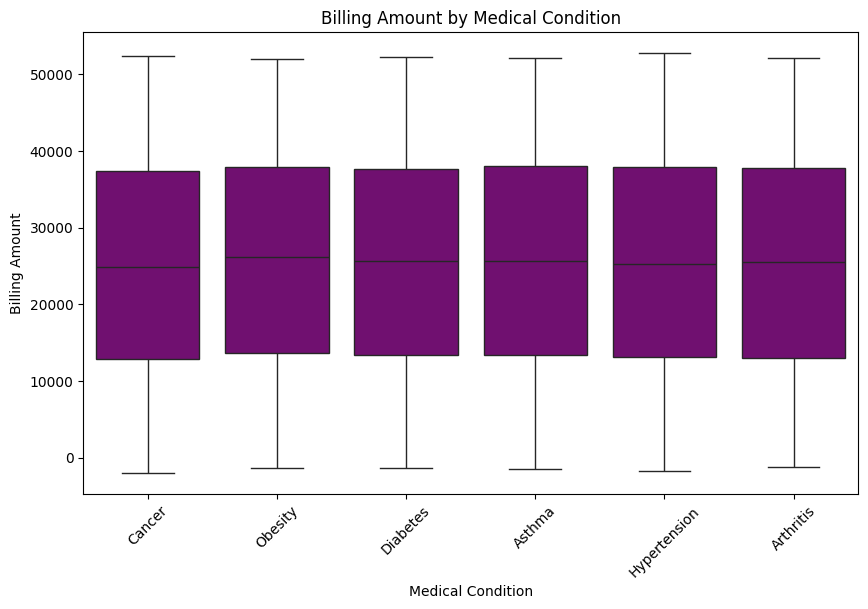

In [ ]:
plt.figure(figsize=(10,6))
sns.boxplot(data=df,x="Medical Condition",y="Billing Amount",color="purple")
plt.title("Billing Amount by Medical Condition")
plt.xticks(rotation=45)
plt.show()

# **Test results**

/tmp/ipykernel_4015/920627604.py:2: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:purple'` for the same effect.

  sns.countplot(data=df,x="Test Results",hue="Medical Condition",color="purple")


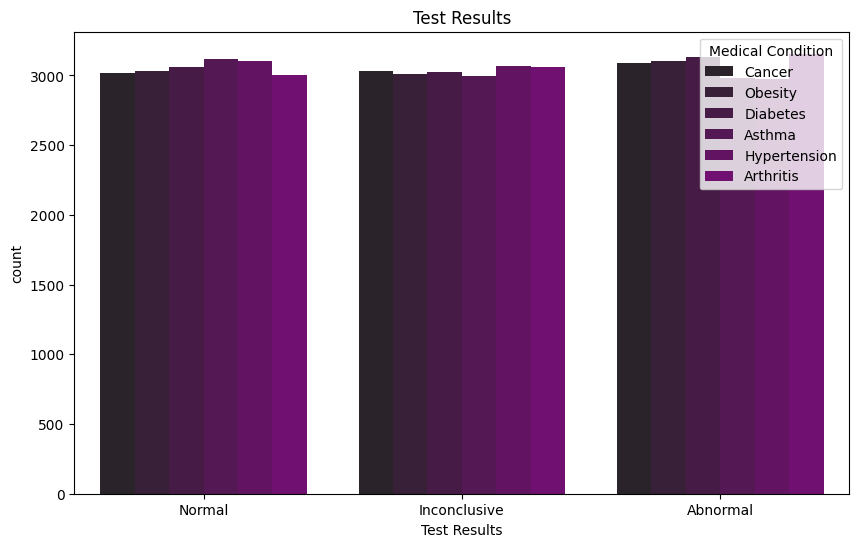

In [ ]:
plt.figure(figsize=(10,6))
sns.countplot(data=df,x="Test Results",hue="Medical Condition",color="purple")
plt.title("Test Results")
plt.show()

" Every listed medical condition (Cancer, obesity,diabetes, Asthma, Hypertension and Arthritis) has a nearly identical count across al three test result groups."

#**Data Preprocessing**

" We should remove coluumns that aren't useful for this prediction.

for example:- Name, Doctor Hospital, Dates,Date of admission,Discharge date . "

In [ ]:
drop_columns = ["Name","Doctor","Hospital","Date of Admission","Discharge Date"]
df=df.drop(drop_columns,axis=1,errors="ignore")


In [ ]:
df.head()

,Age,Gender,Blood Type,Medical Condition,Insurance Provider,Billing Amount,Room Number,Admission Type,Medication,Test Results
0,30,Male,B-,Cancer,Blue Cross,18856.281306,328,Urgent,Paracetamol,Normal
1,62,Male,A+,Obesity,Medicare,33643.327287,265,Emergency,Ibuprofen,Inconclusive
2,76,Female,A-,Obesity,Aetna,27955.096079,205,Emergency,Aspirin,Normal
3,28,Female,O+,Diabetes,Medicare,37909.782410,450,Elective,Ibuprofen,Abnormal
4,43,Female,AB+,Cancer,Aetna,14238.317814,458,Urgent,Penicillin,Abnormal


# **Separate X and Y**

In [ ]:
X= df.drop("Medical Condition",axis=1)
Y=df["Medical Condition"]

In [ ]:
print("X shape:",X.shape)
print("Y shape:",Y.shape)

X shape: (54966, 9)
Y shape: (54966,)


#**Encode categorical variable**

In [ ]:
X= pd.get_dummies(X,drop_first=True)
X.head()

,Age,Billing Amount,Room Number,Gender_Male,Blood Type_A-,Blood Type_AB+,Blood Type_AB-,Blood Type_B+,Blood Type_B-,Blood Type_O+,...,Insurance Provider_Medicare,Insurance Provider_UnitedHealthcare,Admission Type_Emergency,Admission Type_Urgent,Medication_Ibuprofen,Medication_Lipitor,Medication_Paracetamol,Medication_Penicillin,Test Results_Inconclusive,Test Results_Normal
0,30,18856.281306,328,True,False,False,False,False,True,False,...,False,False,False,True,False,False,True,False,False,True
1,62,33643.327287,265,True,False,False,False,False,False,False,...,True,False,True,False,True,False,False,False,True,False
2,76,27955.096079,205,False,True,False,False,False,False,False,...,False,False,True,False,False,False,False,False,False,True
3,28,37909.782410,450,False,False,False,False,False,False,True,...,True,False,False,False,True,False,False,False,False,False
4,43,14238.317814,458,False,False,True,False,False,False,False,...,False,False,False,True,False,False,False,True,False,False


# **Encode target variable**

In [ ]:
from sklearn.preprocessing import LabelEncoder

In [ ]:
label_encoder = LabelEncoder()
y_encoded=label_encoder.fit_transform(Y)
print("Classes:")

for i, class_name in enumerate(label_encoder.classes_):
  print(i,"=",class_name)

Classes:
0 = Arthritis
1 = Asthma
2 = Cancer
3 = Diabetes
4 = Hypertension
5 = Obesity


# **Train-Test Split**

In [ ]:
X_train , X_test , y_train , y_test = train_test_split(X,y_encoded,test_size=0.2,random_state=42,stratify=y_encoded)

In [ ]:
print("X_train shape:",X_train.shape)
print("X_test shape:",X_test.shape)
print("y_train shape:",y_train.shape)
print("y_test shape:",y_test.shape)

X_train shape: (43972, 23)
X_test shape: (10994, 23)
y_train shape: (43972,)
y_test shape: (10994,)


#**Feature Scaling**

In [ ]:
scaler = StandardScaler()


In [ ]:
X_train_scaled= scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# **Logistic Regression**

In [ ]:
logistic_model = LogisticRegression()
logistic_model.fit(X_train_scaled,y_train)

LogisticRegression()

In [ ]:
y_pred_lr = logistic_model.predict(X_test_scaled)


In [ ]:
accuracy_score(y_test,y_pred_lr)*100

16.381662725122794

# **Decision Tree**

In [ ]:
dt_model = DecisionTreeClassifier(random_state=42,max_depth=10)
dt_model.fit(X_train_scaled,y_train)

DecisionTreeClassifier(max_depth=10, random_state=42)

In [ ]:
y_pred_dt= dt_model.predict(X_test_scaled)

In [ ]:
accuracy_score_dt = accuracy_score(y_test,y_pred_dt)*100
print("Accuracy Score:",accuracy_score_dt)


Accuracy Score: 17.036565399308714


# **Random Forest**

In [ ]:
rf_model =RandomForestClassifier(n_estimators=100,random_state=42)


In [ ]:
rf_model.fit(X_train_scaled,y_train)

RandomForestClassifier(random_state=42)

In [ ]:
y_pred_rf = rf_model.predict(X_test_scaled)

In [ ]:
accuracy_score_rf = accuracy_score(y_test,y_pred_rf)*100
print("Accuracy Score:",accuracy_score_rf)

Accuracy Score: 28.533745679461525


# **KNN**

In [ ]:
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train_scaled,y_train)

KNeighborsClassifier()

In [ ]:
y_pred_knn = knn_model.predict(X_test_scaled)

In [ ]:
accuracy_score_knn = accuracy_score(y_test,y_pred_knn)*100
print("Accuracy Score:",accuracy_score_knn)

Accuracy Score: 19.537929779879935


# **Compare all models**

In [ ]:
results =pd.DataFrame({
    "Model":["Logistic Regression","Decision Tree","Random Forest","KNN"],
    "Accuracy":[accuracy_score(y_test,y_pred_lr),accuracy_score(y_test,y_pred_dt),accuracy_score(y_test,y_pred_rf),accuracy_score(y_test,y_pred_knn)]
})

In [ ]:
results["Accuracy(%)"]=(results["Accuracy"]*100).round(2)
print(results["Accuracy(%)"])

0    16.38
1    17.04
2    28.53
3    19.54
Name: Accuracy(%), dtype: float64


# **Accuracy Graph**

The graph compares the accuracy of different Machine Learning algorithms:-

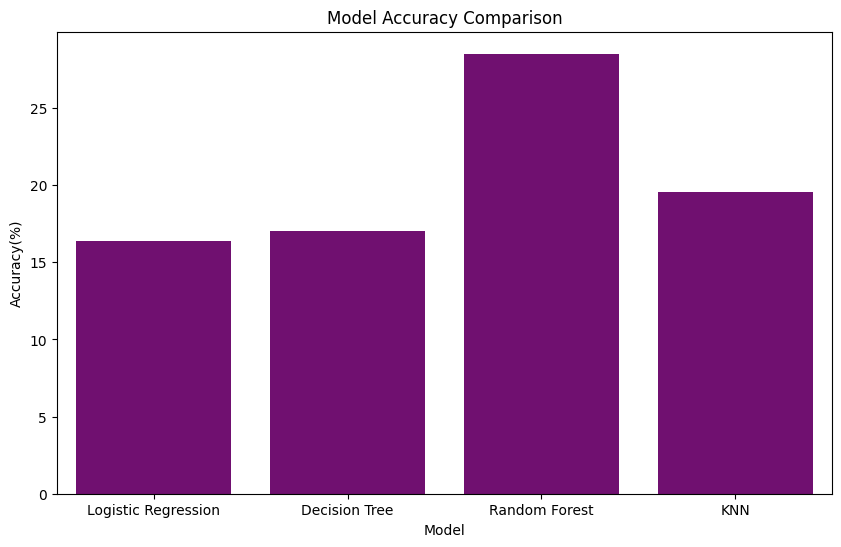

In [ ]:
plt.figure(figsize=(10,6))
sns.barplot(x="Model",y="Accuracy(%)",data=results,color="purple")
plt.title("Model Accuracy Comparison")
plt.show()

" The Random Forest Model with highest test accuracy is considered the best- performing model among those tested."

# Best Model

In [ ]:
best_model_name = results.loc[results["Accuracy(%)"].idxmax(),"Model"]
best_model_accuracy = results.loc[results["Accuracy(%)"].idxmax(),"Accuracy(%)"]
print("Best Model:",best_model_name)
print("Best Accuracy:",best_model_accuracy,"%")

Best Model: Random Forest
Best Accuracy: 28.53 %


" This show Random Forest is the Best Model with higyh accuracy 28.53% ."

# **Random Forest Classification report**

In [ ]:
print(classification_report(y_test,y_pred_rf,target_names=label_encoder.classes_))

              precision    recall  f1-score   support

   Arthritis       0.26      0.27      0.27      1844
      Asthma       0.30      0.30      0.30      1819
      Cancer       0.31      0.30      0.30      1828
    Diabetes       0.28      0.28      0.28      1844
Hypertension       0.28      0.28      0.28      1830
     Obesity       0.28      0.28      0.28      1829

    accuracy                           0.29     10994
   macro avg       0.29      0.29      0.29     10994
weighted avg       0.29      0.29      0.29     10994



" Here we get Precision , Recall , F1-Score and Support Of all Medical Condition."

# **Confusion Matrix**

The confusion  Matrix compares the actual medical condition with the predicted medical conditon.

In [ ]:
cm = confusion_matrix(y_test,y_pred_rf)
print(cm)

[[506 261 284 272 259 262]
 [291 549 232 258 254 235]
 [268 230 553 257 261 259]
 [284 258 232 513 272 285]
 [300 256 246 275 507 246]
 [297 256 262 248 257 509]]


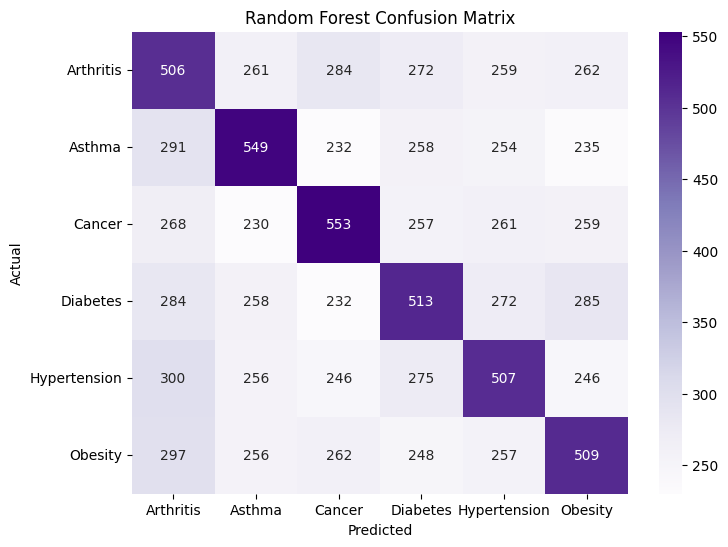

In [ ]:
plt.figure(figsize=(8,6))
sns.heatmap(cm,annot=True,fmt="d",cmap="Purples",xticklabels=label_encoder.classes_,yticklabels=label_encoder.classes_)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Random Forest Confusion Matrix")
plt.show()

" The Diagonal values represent correct prediction, while off- diagonal values represent incorrect prediction."

#**Feature importance**

 Feature importance identifies which variable contributed most to the Random Forest Model's Predictions.

In [ ]:
feature_importance = pd.DataFrame({"Feature":X.columns,"Importance":rf_model.feature_importances_})
feature_importance = feature_importance.sort_values(by="Importance",ascending=False)
feature_importance.head(15)

,Feature,Importance
1,Billing Amount,0.219313
2,Room Number,0.211682
0,Age,0.184944
3,Gender_Male,0.029720
21,Admission Type_Urgent,0.023765
20,Admission Type_Emergency,0.023411
25,Medication_Penicillin,0.019413
22,Medication_Ibuprofen,0.018836
18,Insurance Provider_Medicare,0.018370
24,Medication_Paracetamol,0.018367


# *Graph*

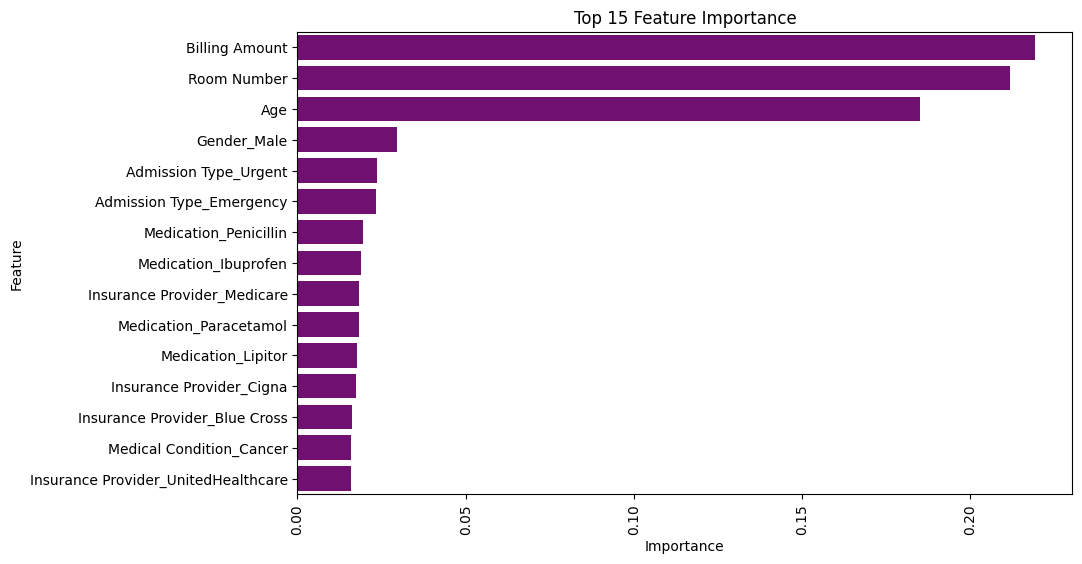

In [ ]:
plt.figure(figsize=(10,6))
sns.barplot(x="Importance",y="Feature",data=feature_importance.head(15),color="Purple")
plt.title("Top 15 Feature Importance")
plt.xticks(rotation=90)
plt.show()

"Features with higher importance values had a greater influence on the classificaion process, while features with lower importance contributesd less to the model."

# **Final Overall Conclusion**

"The Healthcare Dataset was successfully analyzed using Exploratory Data Analysis and machine learning techniques. The analysis included demographic information, medical conditions, admission types, test results, billing amounts, insurance providers, and medications. Multiple classification models were trained and compared. The project demonstrates a complete healthcare data analysis and multi-class classification workflow. Since the dataset is synthetic/dummy data, the results should be considered for educational and machine learning practice purposes rather than real clinical decision-making."